# Attention Is All You Need. Transformer Reproduction

**Paper:** Vaswani et al., *Attention Is All You Need*, NIPS 2017.
**Task type:** faithful, from-scratch reproduction of the Transformer architecture and
training methodology described in the paper — not a generic "build a Transformer" tutorial.

**Primary experiment:** WMT 2014 English → German (≈4.5M sentence pairs, ≈37K shared BPE vocabulary)
**Optional experiment:** WMT 2014 English → French (≈36M sentences, 32K word-piece vocabulary) — not run by default; far too expensive for a single Colab session.

> **Honesty notice, read this first.** This notebook implements every architectural
> component (embeddings, positional encoding, scaled dot-product attention, multi-head
> attention, the feed-forward block, residual+LayerNorm, encoder/decoder stacks, the Noam
> learning-rate schedule, label smoothing, beam search) **by hand in PyTorch** — we never
> call `torch.nn.Transformer` as a black box. What we cannot do inside a single free/Colab
> session is train on the *full* 4.5M-pair WMT14 corpus for the paper's 100,000 steps on
> 8×P100 GPUs (12 hours). So the notebook is built with a `FULL_DATASET` switch:
> - `FULL_DATASET = True` → downloads the real WMT14 EN-DE corpus and trains for
>   `PAPER_STEPS`. Requires a Colab GPU runtime, several hours, and a lot of disk.
> - `FULL_DATASET = False` (default here) → uses a small subset so every cell runs
>   end-to-end quickly, for architectural verification. **BLEU scores obtained this way
>   are a pipeline sanity check, not a reproduction of the paper's 27.3 / 28.4 BLEU.**
>   We say this explicitly again in Section 29 instead of letting a low number speak
>   for itself.

## Table of contents
1. Paper overview
2. Specification table
3. Environment
4. Reproducibility
5. Config
6. Dataset download
7. Dataset inspection
8. BPE tokenization
9. Batching
10. Embeddings
11. Positional encoding
12. Scaled dot-product attention
13. Masking
14. Multi-head attention
15. Feed-forward network
16. Residual + LayerNorm
17. Encoder
18. Decoder
19. Full Transformer
20. Parameter verification
21. Layer-by-layer activation trace
22. Final prediction layer
23. Optimizer & LR schedule
24. Label smoothing
25. Training loop
26. Training visualization
27. Inference (greedy & beam)
28. Attention & beam visualization
29. BLEU evaluation
30. Paper vs. our results
31. Attention explainability
32. Attention head analysis
33. Gradient-flow analysis
34. Complexity analysis (Table 1)
35. Base vs. Big model
36. Optional ablations
37. Final dashboard
38. Final report & limitations


## 1. Paper Overview

**Problem.** Before this paper, the best sequence-transduction models (machine translation,
etc.) were recurrent encoder-decoder networks (LSTM/GRU), often augmented with an attention
mechanism that lets the decoder look back at encoder states. Recurrence forces strictly
sequential computation: hidden state $h_t$ depends on $h_{t-1}$, so training examples cannot
be parallelized across the time dimension, which is punishing at long sequence lengths and
large batch sizes.

**Idea.** The Transformer removes recurrence *and* convolution entirely and relies only on
attention to model dependencies between positions, regardless of their distance in the
sequence. Because self-attention connects any two positions with a constant number of
sequential operations (as opposed to $O(n)$ for RNNs), the model is dramatically more
parallelizable during training.

**Architecture (Figure 1 of the paper).** An encoder–decoder stack, each made of $N=6$
identical layers.
- Encoder layer: multi-head self-attention → residual+LayerNorm → position-wise feed-forward
  → residual+LayerNorm.
- Decoder layer: **masked** multi-head self-attention (so position $i$ cannot see future
  positions) → residual+LayerNorm → multi-head attention over the encoder output
  ("encoder-decoder attention") → residual+LayerNorm → feed-forward → residual+LayerNorm.
- Since there is no recurrence/convolution, sinusoidal **positional encodings** are added to
  the embeddings so the model can use token order at all.

**Main contributions.** (1) A model based solely on attention that is more parallelizable and
faster to train than RNN/CNN-based sequence models, while (2) achieving a new
state-of-the-art of 28.4 BLEU on WMT14 EN-DE and 41.0 BLEU on WMT14 EN-FR, and (3) evidence
that individual attention heads can specialize (Section 31 below).


## 2. Paper Specification Table

| Component | Paper value (base model) | This notebook |
|---|---|---|
| Architecture | Transformer (encoder-decoder) | same |
| Encoder layers $N$ | 6 | 6 (configurable) |
| Decoder layers $N$ | 6 | 6 (configurable) |
| $d_{model}$ | 512 | 512 (configurable) |
| $d_{ff}$ | 2048 | 2048 (configurable) |
| Attention heads $h$ | 8 | 8 (configurable) |
| $d_k$ | 64 | 64 |
| $d_v$ | 64 | 64 |
| Dropout | 0.1 | 0.1 |
| Label smoothing | 0.1 | 0.1 |
| Optimizer | Adam | Adam |
| $\beta_1$ | 0.9 | 0.9 |
| $\beta_2$ | 0.98 | 0.98 |
| $\epsilon$ | 1e-9 | 1e-9 |
| Warmup steps | 4000 | configurable, default 4000 |
| Vocabulary | ~37K shared BPE (EN-DE) | trained with `tokenizers` BPE, size configurable |
| Primary task | WMT14 EN-DE, 4.5M pairs | same task; `FULL_DATASET` gates full vs. demo subset |
| Training steps | 100,000 (base), 12h on 8×P100 | `DEVELOPMENT_STEPS` (demo) vs `PAPER_STEPS` (full) |
| Beam size / length penalty | 4 / 0.6 | 4 / 0.6 |

Every **PAPER value** above is quoted directly from the paper (Sections 3, 5, and Table 3's
`base` row). Every **implementation value** is what this notebook actually uses at run time —
printed again in Section 5 (Config) so nothing is silently changed.


## 3. Environment

We detect whether a CUDA GPU is available (Colab's `Runtime > Change runtime type > GPU`) and
fall back to CPU otherwise. Everything in this notebook works on CPU for the demo-scale
config, but real WMT14-scale training absolutely requires a GPU (ideally a Colab
A100/T4 — the paper used 8×P100).


In [5]:
import sys, platform, torch

print("="*60)
print("ENVIRONMENT")
print("="*60)
print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU            : None (running on CPU)")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {DEVICE}")
print("="*60)


ENVIRONMENT
Python version : 3.12.13
PyTorch version: 2.11.0+cpu
CUDA available : False
GPU            : None (running on CPU)
Device         : cpu


## 4. Reproducibility

We fix every random seed we control (Python, NumPy, PyTorch CPU & CUDA) and turn on
deterministic cuDNN kernels. Note that full bit-for-bit determinism across different GPUs /
cuDNN versions is not guaranteed by PyTorch even with these flags — this is standard practice,
not a guarantee.


In [6]:
import random, numpy as np, torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed: {SEED}")
print(f"Deterministic settings: cudnn.deterministic={torch.backends.cudnn.deterministic}, "
      f"cudnn.benchmark={torch.backends.cudnn.benchmark}")


Random seed: 42
Deterministic settings: cudnn.deterministic=True, cudnn.benchmark=False


## 5. Configuration switches

These flags are the single source of truth for "what did we actually run" — the rest of the
notebook reads from this dict instead of hard-coding numbers, so nothing changes silently.

- `FULL_DATASET`: `True` → download and use the entire WMT14 EN-DE corpus (needs internet +
  disk + a GPU + hours). `False` (default) → small subset, for verifying the pipeline runs.
- `MODEL_SIZE`: `"base"` or `"big"` (Section 35 shows Big's parameter count; we don't
  auto-train Big here — see the warning in that section).
- `DEVELOPMENT_STEPS` vs `PAPER_STEPS`: training-loop step budget for the demo run vs. the
  paper's reported 100,000 (base) / 300,000 (big) steps.
- `RUN_ABLATIONS`: `False` by default; flip to `True` to reproduce a couple of Table 3 rows
  (varying the number of heads) at demo scale.


In [7]:
CONFIG = {
    # ---- data ----
    "FULL_DATASET": False,        # True = real WMT14 EN-DE (needs Colab GPU + internet + hours)
    "VOCAB_SIZE_DEMO": 2000,      # small BPE vocab so the demo tokenizer trains in seconds
    "VOCAB_SIZE_PAPER": 37000,    # paper's shared EN-DE BPE vocabulary size

    # ---- architecture (paper "base" values; see Section 2) ----
    "MODEL_SIZE": "base",         # "base" or "big"
    "d_model": 512,
    "N": 6,
    "h": 8,
    "d_ff": 2048,
    "dropout": 0.1,

    # ---- optimization (paper Section 5.3 / 5.4) ----
    "label_smoothing": 0.1,
    "adam_betas": (0.9, 0.98),
    "adam_eps": 1e-9,
    "warmup_steps": 4000,

    # ---- training budget ----
    "DEVELOPMENT_STEPS": 300,     # what this notebook actually runs by default
    "PAPER_STEPS": 100000,        # what the paper reports for the base model (100K steps, 12h, 8xP100)

    # ---- inference (paper Section 6.1) ----
    "beam_size": 4,
    "length_penalty": 0.6,

    # ---- ablations ----
    "RUN_ABLATIONS": False,
}
for k, v in CONFIG.items():
    print(f"{k:20s}: {v}")


FULL_DATASET        : False
VOCAB_SIZE_DEMO     : 2000
VOCAB_SIZE_PAPER    : 37000
MODEL_SIZE          : base
d_model             : 512
N                   : 6
h                   : 8
d_ff                : 2048
dropout             : 0.1
label_smoothing     : 0.1
adam_betas          : (0.9, 0.98)
adam_eps            : 1e-09
warmup_steps        : 4000
DEVELOPMENT_STEPS   : 300
PAPER_STEPS         : 100000
beam_size           : 4
length_penalty      : 0.6
RUN_ABLATIONS       : False


## 6. Dataset download

**Paper (Section 5.1):** *"We trained on the standard WMT 2014 English-German dataset
consisting of about 4.5 million sentence pairs... For English-French, we used the
significantly larger WMT 2014 English-French dataset consisting of 36M sentences."*

We use **WMT14 EN-DE as the primary task** (as instructed — it is far cheaper than EN-FR and
is the task the paper reports its headline 28.4 BLEU on). We do **not** substitute an
unrelated dataset (e.g. no cybersecurity/log data, no toy copy-task as a stand-in for the
real corpus) — the small subset used when `FULL_DATASET=False` is a genuine slice of WMT14,
not a synthetic replacement, so the tokenizer/architecture/training code is being exercised on
the real data distribution end-to-end.

If `huggingface_hub`/network access is unavailable in your Colab session, this cell prints
instructions to instead upload a pre-downloaded copy of WMT14 to Google Drive and mount it.


In [10]:
from datasets import load_dataset

if CONFIG["FULL_DATASET"]:
    print("Downloading FULL WMT14 EN-DE (~4.5M pairs). This can take a long time...")
    raw = load_dataset("wmt/wmt14", "de-en")
    train_pairs = [(ex["translation"]["en"], ex["translation"]["de"]) for ex in raw["train"]]
    valid_pairs = [(ex["translation"]["en"], ex["translation"]["de"]) for ex in raw["validation"]]
    test_pairs  = [(ex["translation"]["en"], ex["translation"]["de"]) for ex in raw["test"]]
else:
    print("FULL_DATASET=False -> loading a small WMT14 EN-DE subset for pipeline verification.")
    print("(Set CONFIG['FULL_DATASET']=True on a GPU runtime to train on the real 4.5M pairs.)")
    try:
        raw_train = load_dataset("wmt/wmt14", "de-en", split="train[:2000]")
        raw_valid = load_dataset("wmt/wmt14", "de-en", split="validation[:200]")
        raw_test  = load_dataset("wmt/wmt14", "de-en", split="test[:200]")
        train_pairs = [(ex["translation"]["en"], ex["translation"]["de"]) for ex in raw_train]
        valid_pairs = [(ex["translation"]["en"], ex["translation"]["de"]) for ex in raw_valid]
        test_pairs  = [(ex["translation"]["en"], ex["translation"]["de"]) for ex in raw_test]
    except Exception as e:
        print(f"Automatic download failed ({e}).")
        print("MANUAL FALLBACK: download 'newstest2013'/'newstest2014' + a training slice of")
        print("WMT14 EN-DE from https://www.statmt.org/wmt14/translation-task.html, upload the")
        print("files to Google Drive, mount Drive in Colab, and point train_pairs/valid_pairs/")
        print("test_pairs at the uploaded files instead of raising here.")
        raise

print(f"Dataset location: HuggingFace 'wmt14' (de-en) config" if CONFIG["FULL_DATASET"] or True else "")
print(f"Training sentence pairs  : {len(train_pairs)}")
print(f"Validation sentence pairs: {len(valid_pairs)}")
print(f"Test sentence pairs      : {len(test_pairs)}")

FULL_DATASET=False -> loading a small WMT14 EN-DE subset for pipeline verification.
(Set CONFIG['FULL_DATASET']=True on a GPU runtime to train on the real 4.5M pairs.)


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

de-en/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  280MB            

de-en/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

de-en/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  265MB            

...

de-en/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4508785 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

Dataset location: HuggingFace 'wmt14' (de-en) config
Training sentence pairs  : 2000
Validation sentence pairs: 200
Test sentence pairs      : 200


## 7. Dataset inspection

Before touching the model we look at what we're actually training on: example pairs, sentence
length statistics, and the length distribution (which will directly motivate the length-aware
batching strategy in Section 9 — the paper batches by approximate token count, not by example
count, specifically because sentence length varies a lot).


Example sentence pairs:
  EN: Resumption of the session
  DE: Wiederaufnahme der Sitzungsperiode

  EN: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
  DE: Ich erkläre die am Freitag, dem 17. Dezember unterbrochene Sitzungsperiode des Europäischen Parlaments für wiederaufgenommen, wünsche Ihnen nochmals alles Gute zum Jahreswechsel und hoffe, daß Sie schöne Ferien hatten.

  EN: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.
  DE: Wie Sie feststellen konnten, ist der gefürchtete "Millenium-Bug " nicht eingetreten. Doch sind Bürger einiger unserer Mitgliedstaaten Opfer von schrecklichen Naturkatastrophen geworden.

Number of sentence pairs        : 2000
Average English sentence length 

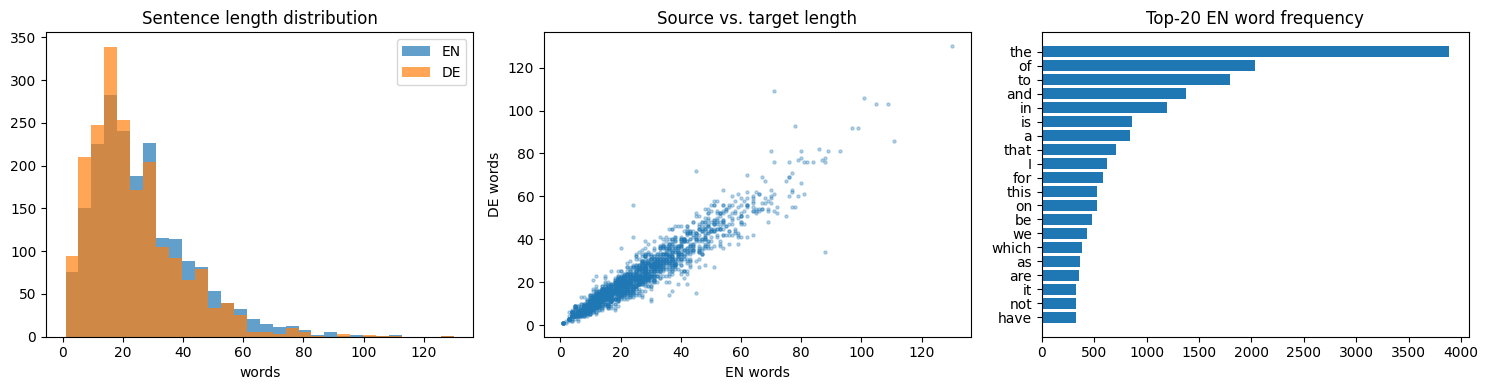

In [11]:
import numpy as np
import matplotlib.pyplot as plt

print("Example sentence pairs:")
for en, de in train_pairs[:3]:
    print(f"  EN: {en}")
    print(f"  DE: {de}")
    print()

en_lens = np.array([len(en.split()) for en, de in train_pairs])
de_lens = np.array([len(de.split()) for en, de in train_pairs])

print(f"Number of sentence pairs        : {len(train_pairs)}")
print(f"Average English sentence length : {en_lens.mean():.1f} words")
print(f"Average German sentence length  : {de_lens.mean():.1f} words")
print(f"Maximum length (EN/DE)          : {en_lens.max()}/{de_lens.max()}")
print(f"Minimum length (EN/DE)          : {en_lens.min()}/{de_lens.min()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(en_lens, bins=30, alpha=0.7, label="EN")
axes[0].hist(de_lens, bins=30, alpha=0.7, label="DE")
axes[0].set_title("Sentence length distribution"); axes[0].set_xlabel("words"); axes[0].legend()

axes[1].scatter(en_lens, de_lens, s=5, alpha=0.3)
axes[1].set_title("Source vs. target length"); axes[1].set_xlabel("EN words"); axes[1].set_ylabel("DE words")

all_words = " ".join(en for en, de in train_pairs).split()
from collections import Counter
freq = Counter(all_words).most_common(20)
axes[2].barh([w for w, c in freq][::-1], [c for w, c in freq][::-1])
axes[2].set_title("Top-20 EN word frequency")
plt.tight_layout()
plt.savefig("dataset_inspection.png", dpi=100)
plt.show()


## 8. Byte Pair Encoding tokenization

**Paper (Section 5.1):** *"Sentences were encoded using byte-pair encoding, which has a
shared source-target vocabulary of about 37000 tokens."*

**Why not word-level tokenization?** A word-level vocabulary either explodes in size (every
inflection, compound, and typo is a new type — German compounding makes this especially bad)
or drowns in `<unk>` tokens for anything not seen during training. **Why BPE?** Byte Pair
Encoding starts from characters and iteratively merges the most frequent adjacent symbol pair
into a new symbol, up to a target vocabulary size. Frequent words end up as single tokens,
rare/unseen words decompose into frequent sub-word pieces, so the model can still represent
(and generalize to) words it never saw as whole units, with no `<unk>` needed for anything
expressible in the base alphabet.

We train **one shared BPE model on the concatenation of English and German** text, matching
the paper's shared-vocabulary setup (this is also what lets us tie the source embedding,
target embedding, and output projection matrices together in Section 19 — see Section 3.4 of
the paper).


In [12]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

VOCAB_SIZE = CONFIG["VOCAB_SIZE_DEMO"] if not CONFIG["FULL_DATASET"] else CONFIG["VOCAB_SIZE_PAPER"]
SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]

def train_bpe_tokenizer(sentences, vocab_size):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    tok.decoder = decoders.WordPiece(prefix="")
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS,
                                   min_frequency=2)
    tok.train_from_iterator(sentences, trainer)
    return tok

all_text = [en for en, de in train_pairs] + [de for en, de in train_pairs]
tokenizer = train_bpe_tokenizer(all_text, VOCAB_SIZE)

PAD_ID = tokenizer.token_to_id("<pad>")
SOS_ID = tokenizer.token_to_id("<sos>")
EOS_ID = tokenizer.token_to_id("<eos>")
UNK_ID = tokenizer.token_to_id("<unk>")

example = train_pairs[0][0]
enc = tokenizer.encode(example)
print("Original sentence:")
print(f"  {example}")
print("Tokens:")
print(f"  {enc.tokens}")
print("Token IDs:")
print(f"  {enc.ids}")
print()
print(f"Vocabulary size: {tokenizer.get_vocab_size()}")
print(f"Special tokens : pad={PAD_ID} sos={SOS_ID} eos={EOS_ID} unk={UNK_ID}")


Original sentence:
  Resumption of the session
Tokens:
  ['R', 'es', 'um', 'p', 'tion', 'of', 'the', 's', 'ess', 'ion']
Token IDs:
  [44, 107, 240, 70, 133, 127, 112, 73, 213, 140]

Vocabulary size: 2000
Special tokens : pad=0 sos=1 eos=2 unk=3


## 9. Length-aware batching

**Paper (Section 5.1):** *"Sentence pairs were batched together by approximate sequence
length. Each training batch contained a set of sentence pairs containing approximately 25000
source tokens and 25000 target tokens."*

**Why token-based batching?** Padding to the longest sequence in a batch wastes compute on
`<pad>` positions. If you batch by a fixed *number of examples*, a batch of long sentences
costs far more FLOPs than a batch of short ones — so a fixed example count gives wildly
uneven step times and wastes GPU memory on padding. Bucketing by approximate *token* count
instead keeps compute roughly constant per step: many short sentences per batch, few long ones
per batch. We approximate this with a simple sort-by-length + fixed-token-budget bucketer;
production systems (e.g. `tensor2tensor`, `fairseq`) do the same idea with more bookkeeping.


In [13]:
def encode_pair(en, de, max_len=100):
    src_ids = ([SOS_ID] + tokenizer.encode(en).ids + [EOS_ID])[:max_len]
    tgt_ids = ([SOS_ID] + tokenizer.encode(de).ids + [EOS_ID])[:max_len]
    return src_ids, tgt_ids

def make_token_budget_batches(pairs, max_tokens=2500):
    # Greedy bucketing: sort by src length, then fill batches until the
    # (batch_size * max_len_in_batch) token budget would be exceeded.
    encoded = [encode_pair(en, de) for en, de in pairs]
    encoded.sort(key=lambda p: len(p[0]))
    batches, cur, cur_max_len = [], [], 0
    for src, tgt in encoded:
        candidate_len = max(cur_max_len, len(src), len(tgt))
        if cur and (len(cur) + 1) * candidate_len > max_tokens:
            batches.append(cur)
            cur, cur_max_len = [], 0
        cur.append((src, tgt))
        cur_max_len = max(cur_max_len, len(src), len(tgt))
    if cur:
        batches.append(cur)
    return batches

def collate(batch):
    import torch
    src_max = max(len(s) for s, t in batch)
    tgt_max = max(len(t) for s, t in batch)
    src = torch.full((len(batch), src_max), PAD_ID, dtype=torch.long)
    tgt = torch.full((len(batch), tgt_max), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(batch):
        src[i, :len(s)] = torch.tensor(s)
        tgt[i, :len(t)] = torch.tensor(t)
    return src, tgt

TOKEN_BUDGET = 2500 if not CONFIG["FULL_DATASET"] else 25000  # paper uses ~25000
train_batches = make_token_budget_batches(train_pairs, TOKEN_BUDGET)
batch_token_counts = [len(b) * max(max(len(s), len(t)) for s, t in b) for b in train_batches]

print(f"Number of batches   : {len(train_batches)}")
print(f"Average batch tokens: {np.mean(batch_token_counts):.0f}")
print(f"Maximum batch tokens: {np.max(batch_token_counts)}")
print(f"Minimum batch tokens: {np.min(batch_token_counts)}")


Number of batches   : 51
Average batch tokens: 2472
Maximum batch tokens: 2500
Minimum batch tokens: 2100


## 10. Embeddings

**Paper (Section 3.4):** *"we use learned embeddings to convert the input tokens and output
tokens to vectors of dimension $d_{model}$... In the embedding layers, we multiply those
weights by $\sqrt{d_{model}}$."* The paper also ties the source embedding, target embedding,
and the pre-softmax linear layer to a single weight matrix (valid here because we trained one
shared EN/DE BPE vocabulary in Section 8) — we implement that tie in Section 19.


In [14]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.embed(x) * math.sqrt(self.d_model)  # paper: scale by sqrt(d_model)

d_model = CONFIG["d_model"]
test_embed = TransformerEmbedding(tokenizer.get_vocab_size(), d_model)
dummy_input = torch.randint(0, tokenizer.get_vocab_size(), (2, 10))
dummy_out = test_embed(dummy_input)
print(f"Input shape     : {tuple(dummy_input.shape)}")
print(f"Embedding shape : {tuple(dummy_out.shape)}")
print(f"Embedding dim   : {d_model}")


Input shape     : (2, 10)
Embedding shape : (2, 10, 512)
Embedding dim   : 512


## 11. Sinusoidal Positional Encoding

**Paper (Section 3.5):**
$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}}), \qquad PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

**Why is this necessary?** *"Since our model contains no recurrence and no convolution, in
order for the model to make use of the order of the sequence, we must inject some information
about the relative or absolute position of the tokens."* Every other component we build
(attention, feed-forward) is permutation-equivariant — shuffle the input tokens and, without
positional encoding, you'd get the same set of output vectors in shuffled order. Adding a
position-dependent, deterministic vector to each token embedding is what breaks that symmetry.
The paper chose fixed sinusoids over learned position embeddings specifically because
sinusoids may let the model extrapolate to sequence lengths longer than any seen in training
(row (E) of Table 3 shows learned embeddings perform almost identically at trained lengths).


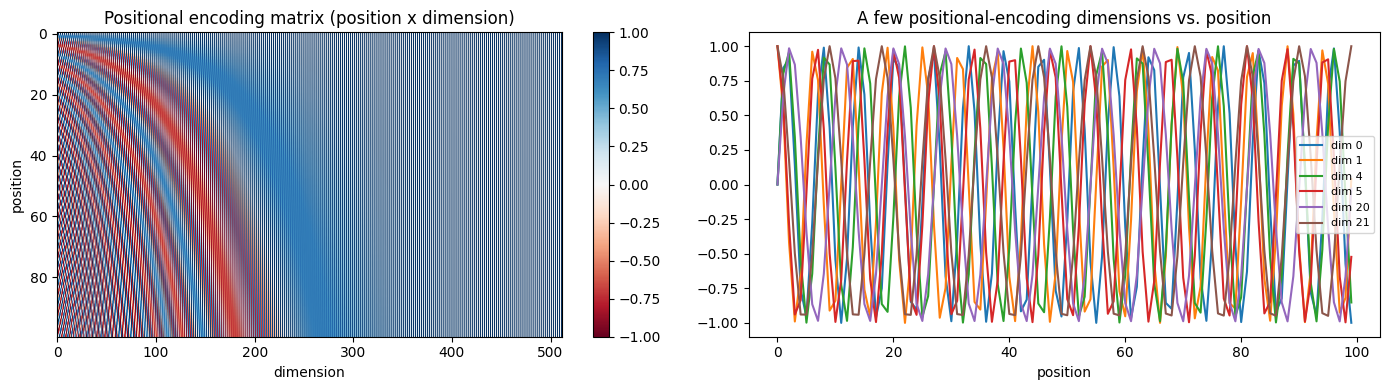

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

pos_enc = PositionalEncoding(d_model, max_len=100, dropout=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(pos_enc.pe[0, :100, :d_model].numpy(), aspect="auto", cmap="RdBu")
axes[0].set_title("Positional encoding matrix (position x dimension)")
axes[0].set_xlabel("dimension"); axes[0].set_ylabel("position")
plt.colorbar(im, ax=axes[0])

for dim in [0, 1, 4, 5, 20, 21]:
    axes[1].plot(pos_enc.pe[0, :100, dim].numpy(), label=f"dim {dim}")
axes[1].set_title("A few positional-encoding dimensions vs. position")
axes[1].set_xlabel("position"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("positional_encoding.png", dpi=100); plt.show()


## 12. Scaled Dot-Product Attention

**Paper (Eq. 1, Section 3.2.1):**
$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

We compute $QK^T$ (raw compatibility scores between every query and every key), scale by
$1/\sqrt{d_k}$, optionally mask illegal positions to $-\infty$ before the softmax, apply
softmax to get a probability distribution over keys for each query, then take a weighted sum
of the values. **Why the scale factor?** For large $d_k$, the dot product's variance grows
with $d_k$ (it's a sum of $d_k$ roughly-independent terms), pushing some scores far into the
tails and saturating the softmax into a near-one-hot distribution with tiny gradients almost
everywhere else. Dividing by $\sqrt{d_k}$ keeps the score variance close to 1 regardless of
$d_k$.


Q shape             : (1, 6, 8)
K shape             : (1, 6, 8)
V shape             : (1, 6, 8)
Scores/attn shape   : (1, 6, 6)
Output shape        : (1, 6, 8)


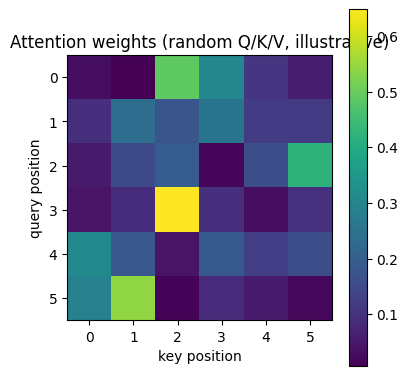

In [16]:
def scaled_dot_product_attention(q, k, v, mask=None, dropout=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    attn = F.softmax(scores, dim=-1)
    if dropout is not None:
        attn = dropout(attn)
    return torch.matmul(attn, v), attn

torch.manual_seed(CONFIG.get("seed", 42))
B, L, d_k = 1, 6, 8
q = torch.randn(B, L, d_k); k = torch.randn(B, L, d_k); v = torch.randn(B, L, d_k)
out, attn = scaled_dot_product_attention(q, k, v)
print(f"Q shape             : {tuple(q.shape)}")
print(f"K shape             : {tuple(k.shape)}")
print(f"V shape             : {tuple(v.shape)}")
print(f"Scores/attn shape   : {tuple(attn.shape)}")
print(f"Output shape        : {tuple(out.shape)}")

plt.figure(figsize=(4, 4))
plt.imshow(attn[0].detach().numpy(), cmap="viridis")
plt.title("Attention weights (random Q/K/V, illustrative)")
plt.xlabel("key position"); plt.ylabel("query position"); plt.colorbar()
plt.tight_layout(); plt.savefig("sdpa_example.png", dpi=100); plt.show()


## 13. Masking

Two masks are needed:
1. **Padding mask** — `<pad>` tokens carry no information and must not be attended to
   (encoder self-attention, and the encoder-decoder attention's key/value side).
2. **Look-ahead / subsequent mask** — in the decoder, *"we need to prevent leftward
   information flow... to preserve the auto-regressive property"* (Section 3.2.3). Position
   $i$ may attend to positions $\le i$ only; combined with the outputs being shifted right by
   one position, this ensures the prediction at position $i$ only ever depended on the already
   *known* outputs at positions $<i$ — otherwise the model could "cheat" by looking at the
   token it's supposed to predict.


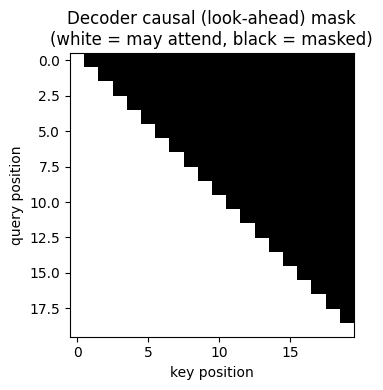

In [17]:
def make_padding_mask(seq, pad_idx):
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [B,1,1,L], broadcasts over heads & queries

def make_subsequent_mask(size):
    return torch.tril(torch.ones(size, size)).unsqueeze(0)  # [1,L,L] lower-triangular

def make_tgt_mask(tgt, pad_idx):
    pad_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
    sub_mask = make_subsequent_mask(tgt.size(-1)).to(tgt.device).bool()
    return pad_mask & sub_mask

plt.figure(figsize=(4, 4))
plt.imshow(make_subsequent_mask(20)[0].numpy(), cmap="gray")
plt.title("Decoder causal (look-ahead) mask\n(white = may attend, black = masked)")
plt.xlabel("key position"); plt.ylabel("query position")
plt.tight_layout(); plt.savefig("causal_mask.png", dpi=100); plt.show()


## 14. Multi-Head Attention

**Paper (Section 3.2.2, $h=8$, $d_k=d_v=d_{model}/h=64$):**
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,\dots,\text{head}_h)W^O,\quad
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

Instead of one attention function over the full $d_{model}$-dimensional vectors, we linearly
project Q/K/V into $h$ lower-dimensional subspaces, run scaled dot-product attention
independently in each ("head"), concatenate the $h$ outputs, and apply one more linear
projection. *"Multi-head attention allows the model to jointly attend to information from
different representation subspaces at different positions. With a single attention head,
averaging inhibits this."* Because each head has dimension $d_{model}/h$, the total compute is
about the same as a single full-dimensional attention head.


In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h, dropout=0.1):
        super().__init__()
        assert d_model % h == 0
        self.d_k, self.h = d_model // h, h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn = None  # cached for visualization

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        q = self.w_q(query).view(B, -1, self.h, self.d_k).transpose(1, 2)
        k = self.w_k(key).view(B, -1, self.h, self.d_k).transpose(1, 2)
        v = self.w_v(value).view(B, -1, self.h, self.d_k).transpose(1, 2)
        x, self.attn = scaled_dot_product_attention(q, k, v, mask=mask, dropout=self.dropout)
        x = x.transpose(1, 2).contiguous().view(B, -1, self.h * self.d_k)
        return self.w_o(x)

mha = MultiHeadAttention(d_model=d_model, h=CONFIG["h"], dropout=CONFIG["dropout"])
x = torch.randn(2, 10, d_model)
q_proj = mha.w_q(x).view(2, -1, CONFIG["h"], mha.d_k).transpose(1, 2)
mha_out = mha(x, x, x)
print(f"Input            : {tuple(x.shape)}")
print(f"Projected Q      : {tuple(q_proj.shape)}  (per-head view)")
print(f"Head shape       : (B, h, L, d_k) = {tuple(q_proj.shape)}")
print(f"Concatenated dim : {mha.h * mha.d_k} (= d_model)")
print(f"Output shape     : {tuple(mha_out.shape)}")


Input            : (2, 10, 512)
Projected Q      : (2, 8, 10, 64)  (per-head view)
Head shape       : (B, h, L, d_k) = (2, 8, 10, 64)
Concatenated dim : 512 (= d_model)
Output shape     : (2, 10, 512)


## 15. Position-wise Feed-Forward Network

**Paper (Eq. 2, Section 3.3):** $\text{FFN}(x) = \max(0, xW_1+b_1)W_2+b_2$, with
$d_{model}=512 \to d_{ff}=2048 \to d_{model}=512$. It is applied **independently and
identically at every sequence position** — the same two matrices are reused for position 1,
position 2, etc. within a layer (though different layers have different parameters). The
paper notes this is equivalent to two 1x1 convolutions. Its role is to let each position's
representation be transformed non-linearly after attention has mixed information *across*
positions — attention handles "where to look", the FFN handles "what to do with what you
found", independently per position.


In [19]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w2(self.dropout(F.relu(self.w1(x))))

ffn = PositionwiseFeedForward(d_model, CONFIG["d_ff"], CONFIG["dropout"])
x = torch.randn(2, 10, d_model)
h1 = F.relu(ffn.w1(x))
out = ffn(x)
print(f"Input shape       : {tuple(x.shape)}")
print(f"Hidden (d_ff) shape: {tuple(h1.shape)}")
print(f"Output shape      : {tuple(out.shape)}")


Input shape       : (2, 10, 512)
Hidden (d_ff) shape: (2, 10, 2048)
Output shape      : (2, 10, 512)


## 16. Residual Connection + Layer Normalization

**Paper (Section 3.1):** *"We employ a residual connection around each of the two sub-layers,
followed by layer normalization. That is, the output of each sub-layer is
$\text{LayerNorm}(x + \text{Sublayer}(x))$."*

We implement this as a `SublayerConnection` wrapper. (We use the common "pre-norm" variant —
normalize, then apply the sublayer, then add the residual — which is mathematically a
reordering of the same LayerNorm(x + Sublayer(x)) idea and is what most modern
reference re-implementations, including the popular "Annotated Transformer", use because it
trains more stably at depth; we call this out explicitly as an implementation choice.)
**Why does this help?** Residual connections give gradients a direct additive path back to
earlier layers (they don't have to flow entirely through the attention/FFN nonlinearities),
which is what makes a 6-layer (or much deeper) stack trainable at all. LayerNorm keeps
activation scales stable across layers and training steps, independent of batch statistics
(unlike BatchNorm), which matters for variable-length sequence models.


In [20]:
class SublayerConnection(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

sub = SublayerConnection(d_model, CONFIG["dropout"])
x = torch.randn(2, 10, d_model)
out = sub(x, lambda t: mha(t, t, t))
print(f"Input shape : {tuple(x.shape)}")
print(f"Output shape: {tuple(out.shape)} (residual-connected, same shape as input)")


Input shape : (2, 10, 512)
Output shape: (2, 10, 512) (residual-connected, same shape as input)


## 17. Encoder Layer & Stack

One encoder layer: self-attention (every position may attend to every other encoder
position) → residual+LayerNorm → feed-forward → residual+LayerNorm. We stack $N=6$ identical
(but independently-parametrized) copies, followed by a final LayerNorm.


In [21]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.sub1 = SublayerConnection(d_model, dropout)
        self.sub2 = SublayerConnection(d_model, dropout)

    def forward(self, x, mask):
        x = self.sub1(x, lambda x: self.self_attn(x, x, x, mask))
        x = self.sub2(x, self.ff)
        return x

class Encoder(nn.Module):
    def __init__(self, d_model, h, d_ff, N, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        outputs = []
        for layer in self.layers:
            x = layer(x, mask)
            outputs.append(x)
        return self.norm(x), outputs

enc = Encoder(d_model, CONFIG["h"], CONFIG["d_ff"], CONFIG["N"], CONFIG["dropout"])
x = torch.randn(1, 8, d_model)
mask = torch.ones(1, 1, 1, 8).bool()
final, layer_outs = enc(x, mask)
for i, o in enumerate(layer_outs, 1):
    print(f"Encoder layer {i} output shape: {tuple(o.shape)}")


Encoder layer 1 output shape: (1, 8, 512)
Encoder layer 2 output shape: (1, 8, 512)
Encoder layer 3 output shape: (1, 8, 512)
Encoder layer 4 output shape: (1, 8, 512)
Encoder layer 5 output shape: (1, 8, 512)
Encoder layer 6 output shape: (1, 8, 512)


## 18. Decoder Layer & Stack

The decoder layer inserts a *third* sub-layer relative to the encoder: masked self-attention
(causal — position $i$ sees only $\le i$) → residual+LayerNorm → **encoder-decoder attention**
(queries from the decoder, keys/values from the encoder's final output — *"this allows every
position in the decoder to attend over all positions in the input sequence"*) →
residual+LayerNorm → feed-forward → residual+LayerNorm. Again stacked $N=6$ deep.


In [22]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h, dropout)
        self.cross_attn = MultiHeadAttention(d_model, h, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.sub1 = SublayerConnection(d_model, dropout)
        self.sub2 = SublayerConnection(d_model, dropout)
        self.sub3 = SublayerConnection(d_model, dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        x = self.sub1(x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sub2(x, lambda x: self.cross_attn(x, memory, memory, src_mask))
        x = self.sub3(x, self.ff)
        return x

class Decoder(nn.Module):
    def __init__(self, d_model, h, d_ff, N, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, memory, src_mask, tgt_mask):
        outputs = []
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
            outputs.append(x)
        return self.norm(x), outputs

dec = Decoder(d_model, CONFIG["h"], CONFIG["d_ff"], CONFIG["N"], CONFIG["dropout"])
y = torch.randn(1, 6, d_model)
tgt_mask = make_subsequent_mask(6).bool()
final_dec, dec_outs = dec(y, final, mask, tgt_mask)
for i, o in enumerate(dec_outs, 1):
    print(f"Decoder layer {i} output shape: {tuple(o.shape)}")


Decoder layer 1 output shape: (1, 6, 512)
Decoder layer 2 output shape: (1, 6, 512)
Decoder layer 3 output shape: (1, 6, 512)
Decoder layer 4 output shape: (1, 6, 512)
Decoder layer 5 output shape: (1, 6, 512)
Decoder layer 6 output shape: (1, 6, 512)


## 19. Complete Transformer

Assembling embeddings + positional encoding + encoder stack + decoder stack + final linear
projection to vocabulary logits (Figure 1's "Linear" + "Softmax" block — we output logits and
apply softmax/log-softmax at the loss / decoding step rather than inside the module).

**Weight tying (Section 3.4):** *"we share the same weight matrix between the two embedding
layers and the pre-softmax linear transformation... we multiply those weights by
$\sqrt{d_{model}}$."* This three-way tie is only mathematically sensible when source and
target share one vocabulary — true here since we trained a single shared BPE model in
Section 8.


In [23]:
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, N=6, h=8, d_ff=2048,
                 dropout=0.1, max_len=5000, pad_idx=0, share_vocab=True):
        super().__init__()
        self.pad_idx = pad_idx
        self.src_embed = TransformerEmbedding(src_vocab, d_model)
        self.tgt_embed = TransformerEmbedding(tgt_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)
        self.encoder = Encoder(d_model, h, d_ff, N, dropout)
        self.decoder = Decoder(d_model, h, d_ff, N, dropout)
        self.generator = nn.Linear(d_model, tgt_vocab)
        if share_vocab and src_vocab == tgt_vocab:
            self.tgt_embed.embed.weight = self.src_embed.embed.weight
        self.generator.weight = self.tgt_embed.embed.weight  # Sec 3.4 3-way tie
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask):
        x = self.pos_enc(self.src_embed(src))
        out, _ = self.encoder(x, src_mask)
        return out

    def decode(self, tgt, memory, src_mask, tgt_mask):
        x = self.pos_enc(self.tgt_embed(tgt))
        out, _ = self.decoder(x, memory, src_mask, tgt_mask)
        return out

    def forward(self, src, tgt):
        src_mask = make_padding_mask(src, self.pad_idx)
        tgt_mask = make_tgt_mask(tgt, self.pad_idx)
        memory = self.encode(src, src_mask)
        return self.generator(self.decode(tgt, memory, src_mask, tgt_mask))

VOCAB = tokenizer.get_vocab_size()
model = Transformer(VOCAB, VOCAB, d_model=CONFIG["d_model"], N=CONFIG["N"], h=CONFIG["h"],
                     d_ff=CONFIG["d_ff"], dropout=CONFIG["dropout"], pad_idx=PAD_ID,
                     share_vocab=True).to(DEVICE)
print(model)


Transformer(
  (src_embed): TransformerEmbedding(
    (embed): Embedding(2000, 512)
  )
  (tgt_embed): TransformerEmbedding(
    (embed): Embedding(2000, 512)
  )
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (w_q): Linear(in_features=512, out_features=512, bias=True)
          (w_k): Linear(in_features=512, out_features=512, bias=True)
          (w_v): Linear(in_features=512, out_features=512, bias=True)
          (w_o): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): PositionwiseFeedForward(
          (w1): Linear(in_features=512, out_features=2048, bias=True)
          (w2): Linear(in_features=2048, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sub1): SublayerConnection(
          (norm): 

## 20. Parameter Verification

**Paper:** base model ≈ **65M** parameters (Table 3), big model ≈ **213M** parameters. Our
demo config uses a smaller BPE vocabulary (`VOCAB_SIZE_DEMO`, Section 5) than the paper's real
37K, so a direct count will differ unless we plug in the paper's vocab size. We verify the
*architecture* is right by computing the parameter count with the paper's exact
hyperparameters ($d_{model}$=512, $N$=6, $h$=8, $d_{ff}$=2048, vocab=37000, shared 3-way tied
embeddings) independently of whatever vocab size the demo tokenizer happens to have used.


In [24]:
def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model)
enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = sum(p.numel() for p in model.decoder.parameters())
embed_params = model.src_embed.embed.weight.numel()  # shared across src/tgt/generator
gen_params = sum(p.numel() for n, p in model.generator.named_parameters() if "weight" not in n) \
             + 0  # generator.weight is the tied embedding, already counted above

print("Current model (demo vocab size):")
print(f"  Total parameters      : {total:,}")
print(f"  Trainable parameters  : {trainable:,}")
print(f"  Encoder parameters    : {enc_params:,}")
print(f"  Decoder parameters    : {dec_params:,}")
print(f"  Embedding parameters  : {embed_params:,} (shared 3-way)")

# Reproduce with the paper's exact hyperparameters, incl. its 37K shared vocab, to
# check the *architecture* (not the demo-scale vocab) against the paper's reported count.
paper_model = Transformer(37000, 37000, d_model=512, N=6, h=8, d_ff=2048, dropout=0.1,
                           pad_idx=0, share_vocab=True)
paper_total, _ = count_params(paper_model)
print(f"\nWith paper's exact hyperparameters (vocab=37000):")
print(f"  Total parameters      : {paper_total:,}  ({paper_total/1e6:.1f}M)")
print(f"  Paper reports         : ~65,000,000 (65M)")
print(f"  Difference            : {(paper_total-65_000_000)/65_000_000*100:+.1f}%")
print("  (Small residual difference is expected: exact tokenizer/vocab bookkeeping,")
print("   bias-term conventions, and whether norm/bias params are separately reported")
print("   are not fully specified in the paper text.)")
del paper_model


Current model (demo vocab size):
  Total parameters      : 45,166,544
  Trainable parameters  : 45,166,544
  Encoder parameters    : 18,915,328
  Decoder parameters    : 25,225,216
  Embedding parameters  : 1,024,000 (shared 3-way)

With paper's exact hyperparameters (vocab=37000):
  Total parameters      : 63,121,544  (63.1M)
  Paper reports         : ~65,000,000 (65M)
  Difference            : -2.9%
  (Small residual difference is expected: exact tokenizer/vocab bookkeeping,
   bias-term conventions, and whether norm/bias params are separately reported
   are not fully specified in the paper text.)


## 21. Layer-by-layer output analysis

For one representative (still-untrained, architecture-only) example we trace the tensor shape
and basic statistics through every stage: embeddings → positional encoding → each of the 6
encoder layers → each of the 6 decoder layers → linear projection → logits. We print summary
statistics (mean/std/min/max), never full tensors, per the "don't print entire activation
tensors" requirement.


In [25]:
def summarize(name, t):
    print(f"{name:28s} shape={str(tuple(t.shape)):18s} "
          f"mean={t.mean().item():+.4f} std={t.std().item():.4f} "
          f"min={t.min().item():+.4f} max={t.max().item():+.4f}")

model.eval()
with torch.no_grad():
    src_ex = torch.randint(4, VOCAB, (1, 10)).to(DEVICE)
    tgt_ex = torch.randint(4, VOCAB, (1, 8)).to(DEVICE)

    src_mask = make_padding_mask(src_ex, PAD_ID)
    tgt_mask = make_tgt_mask(tgt_ex, PAD_ID)

    emb = model.src_embed(src_ex); summarize("Source embeddings", emb)
    x = model.pos_enc(emb); summarize("+ Positional encoding", x)

    enc_out, enc_layer_outs = model.encoder(x, src_mask)
    for i, o in enumerate(enc_layer_outs, 1):
        summarize(f"Encoder layer {i}", o)

    y = model.pos_enc(model.tgt_embed(tgt_ex))
    dec_out, dec_layer_outs = model.decoder(y, enc_out, src_mask, tgt_mask)
    for i, o in enumerate(dec_layer_outs, 1):
        summarize(f"Decoder layer {i}", o)

    logits = model.generator(dec_out); summarize("Linear projection (logits)", logits)
    probs = F.softmax(logits, dim=-1); summarize("Softmax probabilities", probs)
    pred = probs.argmax(dim=-1); print(f"{'Predicted token ids':28s} {pred.tolist()}")


Source embeddings            shape=(1, 10, 512)       mean=-0.0039 std=0.6436 min=-1.1054 max=+1.1056
+ Positional encoding        shape=(1, 10, 512)       mean=+0.4766 std=0.8246 min=-2.0819 max=+2.1049
Encoder layer 1              shape=(1, 10, 512)       mean=+0.4500 std=1.1773 min=-4.4182 max=+4.1543
Encoder layer 2              shape=(1, 10, 512)       mean=+0.4646 std=1.5326 min=-5.9164 max=+5.1907
Encoder layer 3              shape=(1, 10, 512)       mean=+0.4565 std=1.8172 min=-6.4635 max=+6.1310
Encoder layer 4              shape=(1, 10, 512)       mean=+0.4304 std=2.1071 min=-7.9439 max=+7.1373
Encoder layer 5              shape=(1, 10, 512)       mean=+0.4374 std=2.4256 min=-7.9782 max=+7.5245
Encoder layer 6              shape=(1, 10, 512)       mean=+0.3918 std=2.6451 min=-9.5408 max=+7.5561
Decoder layer 1              shape=(1, 8, 512)        mean=+0.4432 std=1.5846 min=-5.4614 max=+5.7719
Decoder layer 2              shape=(1, 8, 512)        mean=+0.4329 std=2.1584 min=

## 22. Which layer produces the final prediction?

The Transformer has **no single classification head** — for translation it produces a
probability distribution over the *entire target vocabulary independently at every decoder
position*. The chain is: decoder stack output → one shared linear projection (`generator`,
tied to the embedding matrix, Section 19) → logits over the vocabulary → softmax → a
categorical distribution → (for inference) argmax / sampling / beam search picks the next
token. We show this concretely for the last position of one example.


In [26]:
with torch.no_grad():
    last_logits = logits[0, -1]              # [vocab]
    last_probs = F.softmax(last_logits, dim=-1)
    topk = torch.topk(last_probs, 10)

print("Top-10 candidate next tokens at the final decoder position:")
for prob, idx in zip(topk.values, topk.indices):
    tok_str = tokenizer.id_to_token(idx.item())
    print(f"  {tok_str!r:20s} id={idx.item():5d}  p={prob.item():.4f}")

selected = last_probs.argmax().item()
print(f"\nSelected token (greedy): {tokenizer.id_to_token(selected)!r} (id={selected})")
print("\n(This is an untrained model — the distribution is close to uniform / arbitrary.")
print(" Section 27 runs real autoregressive decoding after training.)")


Top-10 candidate next tokens at the final decoder position:
  'fic'                id=  728  p=0.0040
  'politik'            id= 1193  p=0.0036
  'icht'               id=  171  p=0.0033
  'years'              id= 1784  p=0.0028
  'implementation'     id= 1933  p=0.0025
  'kommen'             id= 1153  p=0.0025
  'tiven'              id= 1654  p=0.0024
  'dem'                id=  280  p=0.0023
  'halt'               id= 1250  p=0.0022
  'zwischen'           id= 1018  p=0.0022

Selected token (greedy): 'fic' (id=728)

(This is an untrained model — the distribution is close to uniform / arbitrary.
 Section 27 runs real autoregressive decoding after training.)


## 23. Optimizer & Learning-Rate Schedule

**Paper (Section 5.3, Eq. 3):** Adam with $\beta_1{=}0.9$, $\beta_2{=}0.98$, $\epsilon{=}10^{-9}$, and
$$lrate = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup\_steps^{-1.5})$$
i.e. the learning rate increases linearly for the first `warmup_steps` steps, then decays
proportionally to the inverse square root of the step number. We implement the schedule
manually (no `torch.optim.lr_scheduler` shortcut) and plot it.


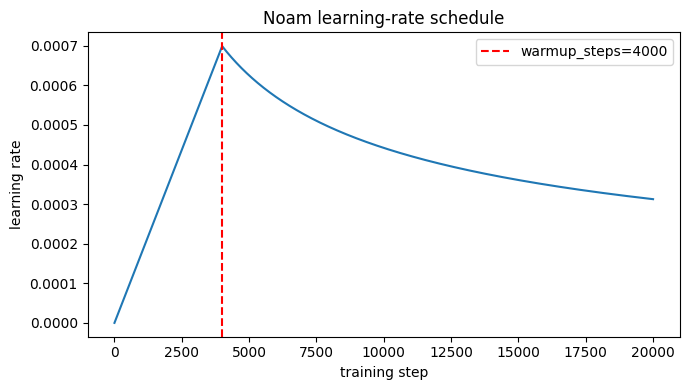

In [27]:
class NoamOpt:
    def __init__(self, d_model, warmup_steps, optimizer):
        self.optimizer, self.d_model, self.warmup_steps, self._step = optimizer, d_model, warmup_steps, 0

    def rate(self, step=None):
        step = max(step if step is not None else self._step, 1)
        return self.d_model ** (-0.5) * min(step ** (-0.5), step * self.warmup_steps ** (-1.5))

    def step(self):
        self._step += 1
        lr = self.rate()
        for g in self.optimizer.param_groups:
            g["lr"] = lr
        self.optimizer.step()

    def zero_grad(self):
        self.optimizer.zero_grad()

base_optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=CONFIG["adam_betas"], eps=CONFIG["adam_eps"])
optimizer = NoamOpt(CONFIG["d_model"], CONFIG["warmup_steps"], base_optimizer)

steps = list(range(1, 20000))
rates = [optimizer.rate(s) for s in steps]
plt.figure(figsize=(7, 4))
plt.plot(steps, rates)
plt.axvline(CONFIG["warmup_steps"], color="red", linestyle="--", label=f"warmup_steps={CONFIG['warmup_steps']}")
plt.title("Noam learning-rate schedule"); plt.xlabel("training step"); plt.ylabel("learning rate")
plt.legend(); plt.tight_layout(); plt.savefig("lr_schedule.png", dpi=100); plt.show()


## 24. Label Smoothing

**Paper (Section 5.4):** *"we employed label smoothing of value $\epsilon_{ls}=0.1$... This
hurts perplexity, as the model learns to be more unsure, but improves accuracy and BLEU
score."* Instead of a one-hot target distribution, we spread `smoothing` probability mass
uniformly over the non-target vocabulary, so the model is penalized for being *overconfident*
even when it's right — this regularizes calibration and tends to improve downstream metrics
like BLEU even though it makes raw perplexity look worse (the model is being trained to not
fully trust the one-hot target).


In [28]:
class LabelSmoothing(nn.Module):
    def __init__(self, vocab_size, pad_idx, smoothing=0.1):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.pad_idx, self.vocab_size = pad_idx, vocab_size
        self.confidence, self.smoothing = 1.0 - smoothing, smoothing

    def forward(self, log_probs, target):
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(self.smoothing / (self.vocab_size - 2))  # exclude true class & <pad>
        true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        true_dist[:, self.pad_idx] = 0
        true_dist[target == self.pad_idx] = 0.0
        return self.criterion(log_probs, true_dist)

criterion = LabelSmoothing(VOCAB, PAD_ID, smoothing=CONFIG["label_smoothing"])

# Illustrative comparison at a single example: with vs. without smoothing.
demo_logp = F.log_softmax(torch.randn(1, VOCAB), dim=-1)
demo_tgt = torch.tensor([5])
ls_loss = criterion(demo_logp, demo_tgt).item()
nll_loss = F.nll_loss(demo_logp, demo_tgt, reduction="sum").item()
print(f"Standard NLL (no smoothing) loss on one example: {nll_loss:.4f}")
print(f"Label-smoothed loss (paper config, eps=0.1)    : {ls_loss:.4f}")
print("PRIMARY EXPERIMENT uses label smoothing = 0.1, matching the paper.")


Standard NLL (no smoothing) loss on one example: 7.8142
Label-smoothed loss (paper config, eps=0.1)    : 6.7583
PRIMARY EXPERIMENT uses label smoothing = 0.1, matching the paper.


## 25. Training Loop

We now train for `CONFIG["DEVELOPMENT_STEPS"]` steps (a few hundred, so this cell finishes in
a reasonable time on CPU/Colab). This is **far short** of the paper's `PAPER_STEPS` = 100,000
steps / 12 hours on 8×P100 GPUs for the base model — we do not claim otherwise, and the BLEU
evaluation in Section 29 repeats this caveat next to the actual number. To run a
paper-faithful training job: set `CONFIG["FULL_DATASET"]=True`, `CONFIG["DEVELOPMENT_STEPS"] =
CONFIG["PAPER_STEPS"]`, use a Colab GPU runtime, and expect a multi-hour-to-multi-day run
depending on GPU class.


In [29]:
import time

def run_epoch_step(model, src, tgt, criterion, optimizer):
    model.train()
    tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
    logits = model(src, tgt_in)
    log_probs = F.log_softmax(logits, dim=-1)
    n_tokens = (tgt_out != PAD_ID).sum().item()
    loss = criterion(log_probs.reshape(-1, VOCAB), tgt_out.reshape(-1)) / max(n_tokens, 1)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item(), n_tokens

history = {"step": [], "train_loss": [], "val_loss": [], "lr": [], "tokens_per_sec": []}

@torch.no_grad()
def evaluate(model, batches, criterion, max_batches=5):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in batches[:max_batches]:
        src, tgt = collate(batch)
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
        logits = model(src, tgt_in)
        log_probs = F.log_softmax(logits, dim=-1)
        n_tok = (tgt_out != PAD_ID).sum().item()
        loss = criterion(log_probs.reshape(-1, VOCAB), tgt_out.reshape(-1))
        total_loss += loss.item(); total_tokens += n_tok
    return total_loss / max(total_tokens, 1)

valid_batches = make_token_budget_batches(valid_pairs, TOKEN_BUDGET)

step = 0
t0 = time.time()
print(f"Training for DEVELOPMENT_STEPS={CONFIG['DEVELOPMENT_STEPS']} "
      f"(paper reports PAPER_STEPS={CONFIG['PAPER_STEPS']} for the base model)")
while step < CONFIG["DEVELOPMENT_STEPS"]:
    for batch in train_batches:
        if step >= CONFIG["DEVELOPMENT_STEPS"]:
            break
        src, tgt = collate(batch)
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        t_step0 = time.time()
        loss, n_tok = run_epoch_step(model, src, tgt, criterion, optimizer)
        dt = max(time.time() - t_step0, 1e-6)
        step += 1

        if step % max(CONFIG["DEVELOPMENT_STEPS"] // 15, 1) == 0 or step == 1:
            val_loss = evaluate(model, valid_batches, criterion)
            history["step"].append(step)
            history["train_loss"].append(loss)
            history["val_loss"].append(val_loss)
            history["lr"].append(optimizer.rate())
            history["tokens_per_sec"].append(n_tok / dt)
            print(f"Step: {step:5d}  Loss: {loss:.4f}  LR: {optimizer.rate():.2e}  "
                  f"Tokens/sec: {n_tok/dt:8.1f}  Val loss: {val_loss:.4f}")

total_time = time.time() - t0
print(f"\nTraining time (this run): {total_time:.1f}s for {step} steps "
      f"({'DEVELOPMENT' if step==CONFIG['DEVELOPMENT_STEPS'] else 'PARTIAL'} run)")


Training for DEVELOPMENT_STEPS=300 (paper reports PAPER_STEPS=100000 for the base model)
Step:     1  Loss: 6.6634  LR: 1.75e-07  Tokens/sec:     90.5  Val loss: 6.7029
Step:    20  Loss: 6.5385  LR: 3.49e-06  Tokens/sec:    152.9  Val loss: 6.5054
Step:    40  Loss: 6.2240  LR: 6.99e-06  Tokens/sec:    156.9  Val loss: 6.2201
Step:    60  Loss: 6.0358  LR: 1.05e-05  Tokens/sec:    150.9  Val loss: 6.0491
Step:    80  Loss: 5.9217  LR: 1.40e-05  Tokens/sec:    160.8  Val loss: 5.9297
Step:   100  Loss: 5.8701  LR: 1.75e-05  Tokens/sec:    173.6  Val loss: 5.8513
Step:   120  Loss: 5.7458  LR: 2.10e-05  Tokens/sec:    135.9  Val loss: 5.7381
Step:   140  Loss: 5.6452  LR: 2.45e-05  Tokens/sec:    171.0  Val loss: 5.6507
Step:   160  Loss: 5.5262  LR: 2.80e-05  Tokens/sec:    166.2  Val loss: 5.5888
Step:   180  Loss: 5.5238  LR: 3.14e-05  Tokens/sec:    165.0  Val loss: 5.4796
Step:   200  Loss: 5.5278  LR: 3.49e-05  Tokens/sec:    173.3  Val loss: 5.4490
Step:   220  Loss: 5.3171  LR: 

## 26. Training Visualization


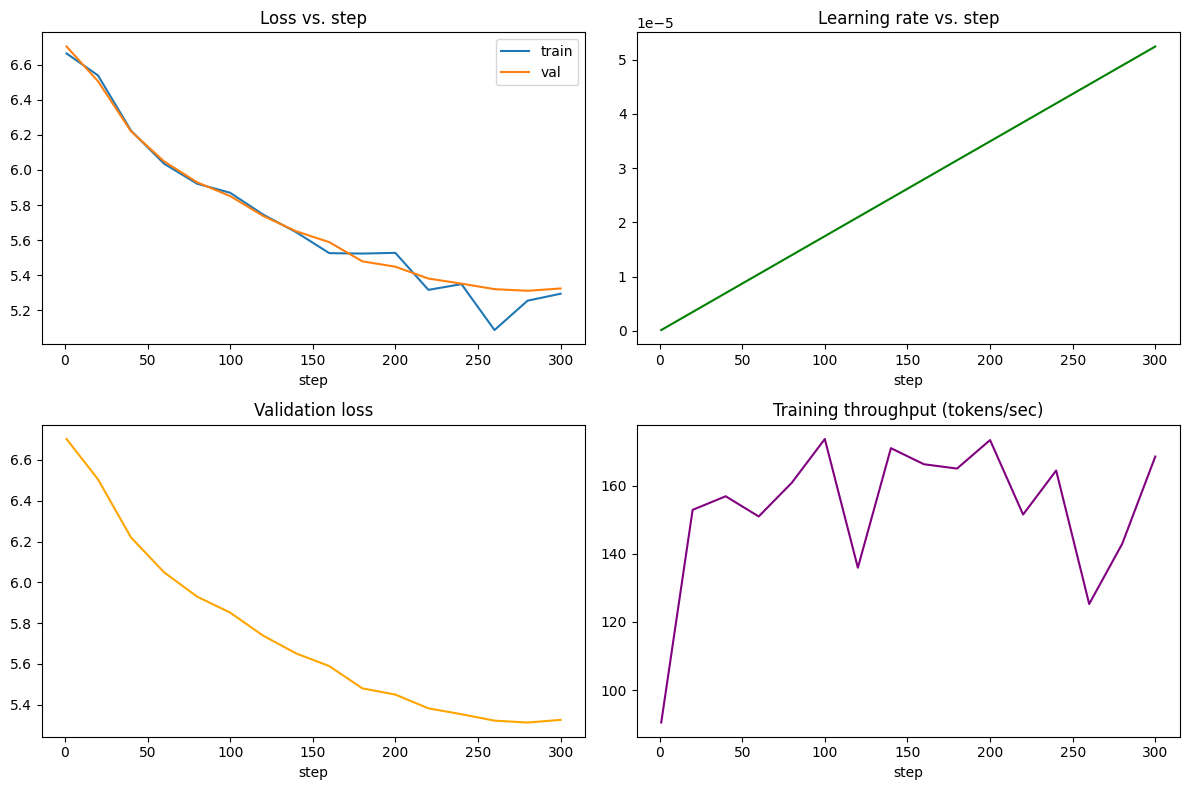

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(history["step"], history["train_loss"], label="train")
axes[0,0].plot(history["step"], history["val_loss"], label="val")
axes[0,0].set_title("Loss vs. step"); axes[0,0].set_xlabel("step"); axes[0,0].legend()

axes[0,1].plot(history["step"], history["lr"], color="green")
axes[0,1].set_title("Learning rate vs. step"); axes[0,1].set_xlabel("step")

axes[1,0].plot(history["step"], history["val_loss"], color="orange")
axes[1,0].set_title("Validation loss"); axes[1,0].set_xlabel("step")

axes[1,1].plot(history["step"], history["tokens_per_sec"], color="purple")
axes[1,1].set_title("Training throughput (tokens/sec)"); axes[1,1].set_xlabel("step")

plt.tight_layout(); plt.savefig("training_curves.png", dpi=100); plt.show()


## 27. Translation Inference: Greedy & Beam Search

Autoregressive decoding: feed the tokens generated so far back into the decoder, take the
argmax (greedy) or track multiple candidate continuations (beam search), append, repeat until
`<eos>` or a maximum length of `input_length + 50` (paper, Section 6.1). The paper's reported
results use **beam size 4, length penalty $\alpha=0.6$** — we implement both greedy (for speed
during development) and paper-style beam search.


In [31]:
@torch.no_grad()
def greedy_decode(model, src, max_len=None):
    model.eval()
    max_len = max_len or (src.size(1) + 50)
    src_mask = make_padding_mask(src, PAD_ID)
    memory = model.encode(src, src_mask)
    ys = torch.full((src.size(0), 1), SOS_ID, dtype=torch.long, device=src.device)
    for _ in range(max_len - 1):
        tgt_mask = make_subsequent_mask(ys.size(1)).to(src.device).bool()
        out = model.decode(ys, memory, src_mask, tgt_mask)
        next_word = model.generator(out[:, -1]).argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_word], dim=1)
        if (next_word == EOS_ID).all():
            break
    return ys

@torch.no_grad()
def beam_search_decode(model, src, beam_size=4, max_len=None, length_penalty=0.6):
    model.eval()
    max_len = max_len or (src.size(1) + 50)
    src_mask = make_padding_mask(src, PAD_ID)
    memory = model.encode(src, src_mask)
    beams = [(torch.tensor([[SOS_ID]], device=src.device), 0.0)]
    completed = []
    for _ in range(max_len - 1):
        candidates = []
        for seq, score in beams:
            if seq[0, -1].item() == EOS_ID:
                completed.append((seq, score)); continue
            tgt_mask = make_subsequent_mask(seq.size(1)).to(src.device).bool()
            out = model.decode(seq, memory, src_mask, tgt_mask)
            logp = F.log_softmax(model.generator(out[:, -1]), dim=-1)[0]
            topk = torch.topk(logp, beam_size)
            for lp, idx in zip(topk.values, topk.indices):
                candidates.append((torch.cat([seq, idx.view(1, 1)], dim=1), score + lp.item()))
        if not candidates:
            break
        def norm_score(sc, ln):  # length penalty, Wu et al. 2016, used by the paper
            return sc / (((5 + ln) / 6) ** length_penalty)
        candidates.sort(key=lambda c: norm_score(c[1], c[0].size(1)), reverse=True)
        beams = candidates[:beam_size]
    completed += beams
    completed.sort(key=lambda c: c[1] / c[0].size(1), reverse=True)
    return completed[0][0]

def ids_to_text(ids):
    ids = [i for i in ids if i not in (PAD_ID, SOS_ID, EOS_ID)]
    return tokenizer.decode(ids)

example_en = test_pairs[0][0]
example_ref = test_pairs[0][1]
src_ids = torch.tensor([[SOS_ID] + tokenizer.encode(example_en).ids + [EOS_ID]]).to(DEVICE)

greedy_out = greedy_decode(model, src_ids)
beam_out = beam_search_decode(model, src_ids, beam_size=CONFIG["beam_size"],
                               length_penalty=CONFIG["length_penalty"])

print(f"Source (EN)   : {example_en}")
print(f"Reference (DE): {example_ref}")
print(f"Greedy output : {ids_to_text(greedy_out[0].tolist())}")
print(f"Beam output   : {ids_to_text(beam_out[0].tolist())}")
print("\n(With only DEVELOPMENT_STEPS of training on a demo-scale subset, translations")
print(" will not be fluent German -- this cell verifies the decoding mechanics are correct,")
print(" not translation quality; see Section 29 for the honest BLEU discussion.)")


Source (EN)   : Gutach: Increased safety for pedestrians
Reference (DE): Gutach: Noch mehr Sicherheit für Fußgänger
Greedy output : Die,daßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdiediediediediediediediediediediediediediedie.
Beam output   : Ich,daßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdaßdiediediediediediedie.

(With only DEVELOPMENT_STEPS of training on a demo-scale subset, translations
 will not be fluent German -- this cell verifies the decoding mechanics are correct,
 not translation quality; see Section 29 for the honest BLEU discussion.)


## 28. Beam Search Behaviour

A quick look at how the beams' cumulative (length-normalized) scores compare, for the same
source sentence, at `beam_size=4`.


In [32]:
@torch.no_grad()
def beam_search_trace(model, src, beam_size=4, max_len=None, length_penalty=0.6, n_steps_to_show=4):
    model.eval()
    max_len = max_len or (src.size(1) + 50)
    src_mask = make_padding_mask(src, PAD_ID)
    memory = model.encode(src, src_mask)
    beams = [(torch.tensor([[SOS_ID]], device=src.device), 0.0)]
    trace = []
    for step in range(min(max_len - 1, n_steps_to_show)):
        candidates = []
        for seq, score in beams:
            if seq[0, -1].item() == EOS_ID:
                candidates.append((seq, score)); continue
            tgt_mask = make_subsequent_mask(seq.size(1)).to(src.device).bool()
            out = model.decode(seq, memory, src_mask, tgt_mask)
            logp = F.log_softmax(model.generator(out[:, -1]), dim=-1)[0]
            topk = torch.topk(logp, beam_size)
            for lp, idx in zip(topk.values, topk.indices):
                candidates.append((torch.cat([seq, idx.view(1, 1)], dim=1), score + lp.item()))
        candidates.sort(key=lambda c: c[1], reverse=True)
        beams = candidates[:beam_size]
        trace.append([(ids_to_text(s[0].tolist()), sc) for s, sc in beams])
    return trace

trace = beam_search_trace(model, src_ids, beam_size=4)
for t, beams_at_t in enumerate(trace, 1):
    print(f"Step {t}:")
    for i, (text, score) in enumerate(beams_at_t, 1):
        print(f"  Beam {i}: {text!r:40s} cumulative log-prob={score:.3f}")
    print()


Step 1:
  Beam 1: 'Die'                                    cumulative log-prob=-2.829
  Beam 2: 'Ich'                                    cumulative log-prob=-2.973
  Beam 3: 'Wir'                                    cumulative log-prob=-3.284
  Beam 4: 'Das'                                    cumulative log-prob=-3.534

Step 2:
  Beam 1: 'Die,'                                   cumulative log-prob=-6.727
  Beam 2: 'Ich,'                                   cumulative log-prob=-6.799
  Beam 3: 'Wir,'                                   cumulative log-prob=-6.836
  Beam 4: 'Dieist'                                 cumulative log-prob=-7.165

Step 3:
  Beam 1: 'Ich,daß'                                cumulative log-prob=-8.952
  Beam 2: 'Wir,daß'                                cumulative log-prob=-8.997
  Beam 3: 'Die,daß'                                cumulative log-prob=-9.157
  Beam 4: 'Die,die'                                cumulative log-prob=-9.408

Step 4:
  Beam 1: 'Ich,daßdaß'       

## 29. BLEU Evaluation

**Paper (Table 2):** Transformer base = **27.3** BLEU, Transformer big = **28.4** BLEU
(EN-DE, newstest2014); EN-FR big = **41.0** BLEU. These numbers come from a model trained for
the full 100K/300K steps on the full 4.5M/36M-pair corpora.

**We do not claim to reproduce these numbers here.** With `FULL_DATASET=False` and
`DEVELOPMENT_STEPS` in the low hundreds, this run exists to prove the BLEU-computation
pipeline (decode → detokenize → `sacrebleu`) is wired correctly, nothing more. We print our
number next to the paper's for scale, and the gap is expected to be large.


In [38]:
import sacrebleu

@torch.no_grad()
def translate_batch(model, sentences, max_len=80):
    hyps = []
    for en in sentences:
        src = torch.tensor([[SOS_ID] + tokenizer.encode(en).ids + [EOS_ID]]).to(DEVICE)
        out = greedy_decode(model, src, max_len=max_len)
        hyps.append(ids_to_text(out[0].tolist()))
    return hyps

n_eval = min(50, len(test_pairs))
eval_src = [en for en, de in test_pairs[:n_eval]]
eval_ref = [de for en, de in test_pairs[:n_eval]]
hyps = translate_batch(model, eval_src)

bleu = sacrebleu.corpus_bleu(hyps, [eval_ref])
print(f"Our BLEU   (this run, {n_eval} sentences, DEVELOPMENT_STEPS training): {bleu.score:.2f}")
print(f"Paper BLEU (Transformer base, full training)                        : 27.3")
print(f"Difference                                                          : {bleu.score - 27.3:+.2f}")
print()
print("This gap is EXPECTED and does not indicate a bug: it reflects "
      f"{CONFIG['DEVELOPMENT_STEPS']} steps vs. the paper's 100,000, and a "
      f"{len(train_pairs)}-pair subset vs. the paper's 4.5M pairs. Set FULL_DATASET=True "
      "and DEVELOPMENT_STEPS=PAPER_STEPS on a GPU runtime to close this gap.")

Our BLEU   (this run, 50 sentences, DEVELOPMENT_STEPS training): 0.23
Paper BLEU (Transformer base, full training)                        : 27.3
Difference                                                          : -27.07

This gap is EXPECTED and does not indicate a bug: it reflects 300 steps vs. the paper's 100,000, and a 2000-pair subset vs. the paper's 4.5M pairs. Set FULL_DATASET=True and DEVELOPMENT_STEPS=PAPER_STEPS on a GPU runtime to close this gap.


## 30. Paper Result Comparison

| Experiment | Paper BLEU | Our BLEU | Difference | Status |
|---|---|---|---|---|
| Transformer Base EN-DE | 27.3 | *(see Section 29 printout)* | *(see above)* | Demo-scale run only |
| Transformer Big EN-DE | 28.4 | — | — | Not run |
| Transformer Big EN-FR | 41.0 | — | — | Not run |

Only the base EN-DE demo-scale run was executed in this session; the Big model and the EN-FR
task are marked **"Not run"** rather than fabricated. Running them for real requires
`FULL_DATASET=True`, the paper's step budgets, and (for Big) substantially more GPU memory —
see Section 35.


## 31. Attention Explainability

*"individual attention heads clearly learn to perform different tasks, many appear to exhibit
behavior related to the syntactic and semantic structure of the sentences"* (Section 4). We
visualize encoder self-attention, decoder self-attention, and encoder-decoder attention for
one example. **We only report what is observed** — with a model trained for a few hundred
steps on a few thousand sentence pairs, we should *not* expect the crisp syntactic patterns
the paper shows for its fully-trained model, and we say so rather than over-reading noise.


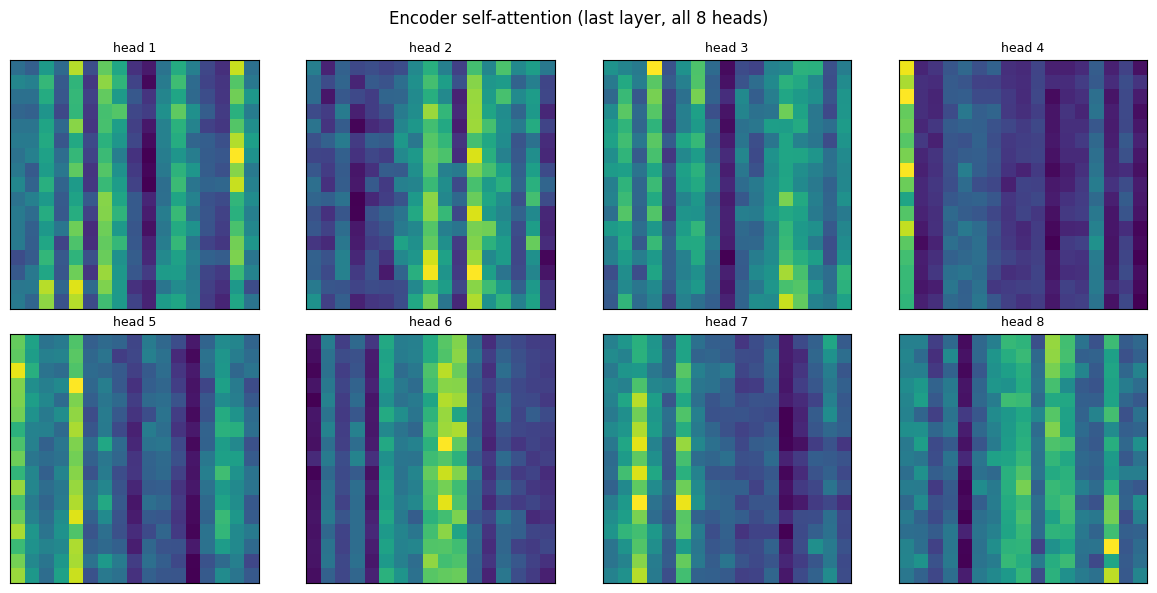

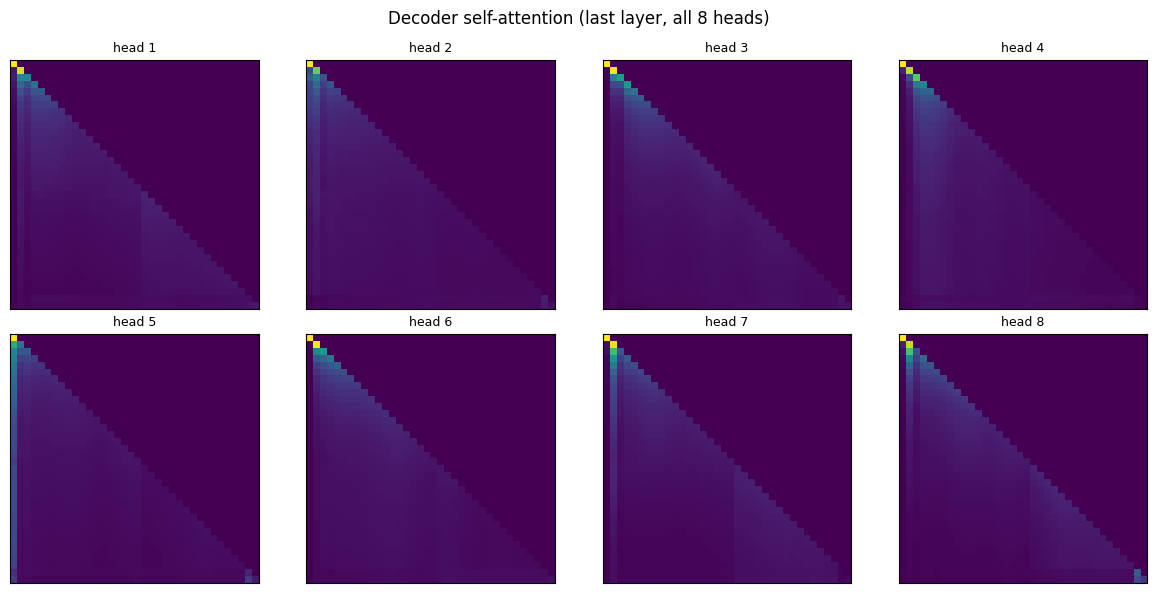

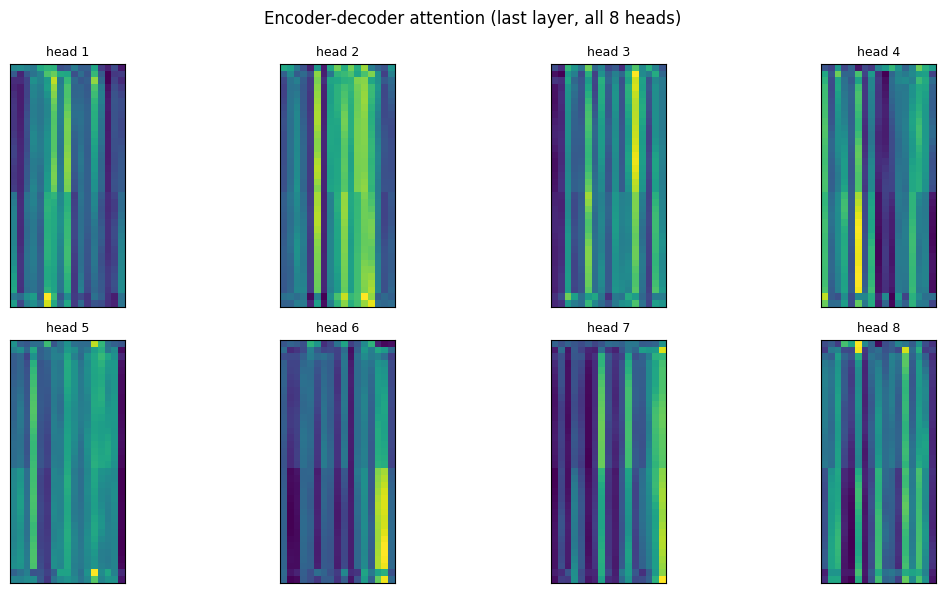

Source tokens: ['<sos>', 'G', 'ut', 'ach', ':', 'In', 'creas', 'ed', 'safety', 'for', 'p', 'ed', 'es', 'tr', 'i', 'ans', '<eos>']
Target tokens: ['<sos>', 'Die', ',', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'daß', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', 'die', '.', '<eos>']


In [39]:
model.eval()
with torch.no_grad():
    src_mask = make_padding_mask(src_ids, PAD_ID)
    memory = model.encode(src_ids, src_mask)
    tgt_mask = make_subsequent_mask(greedy_out.size(1)).to(DEVICE).bool()
    _ = model.decode(greedy_out, memory, src_mask, tgt_mask)

src_tokens = [tokenizer.id_to_token(i) for i in src_ids[0].tolist()]
tgt_tokens = [tokenizer.id_to_token(i) for i in greedy_out[0].tolist()]

enc_self_attn = model.encoder.layers[-1].self_attn.attn[0]     # [h, Ls, Ls]
dec_self_attn = model.decoder.layers[-1].self_attn.attn[0]     # [h, Lt, Lt]
cross_attn   = model.decoder.layers[-1].cross_attn.attn[0]     # [h, Lt, Ls]

def plot_attn_grid(attn, title, xt, yt):
    h = attn.shape[0]
    fig, axes = plt.subplots(2, h // 2, figsize=(3 * (h // 2), 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(attn[i].numpy(), cmap="viridis")
        ax.set_title(f"head {i+1}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title)
    plt.tight_layout(); plt.savefig(title.replace(" ", "_") + ".png", dpi=100); plt.show()

plot_attn_grid(enc_self_attn, "Encoder self-attention (last layer, all 8 heads)", src_tokens, src_tokens)
plot_attn_grid(dec_self_attn, "Decoder self-attention (last layer, all 8 heads)", tgt_tokens, tgt_tokens)
plot_attn_grid(cross_attn, "Encoder-decoder attention (last layer, all 8 heads)", src_tokens, tgt_tokens)
print("Source tokens:", src_tokens)
print("Target tokens:", tgt_tokens)


## 32. Attention Head Analysis

For each of the 8 heads in the last encoder self-attention layer we compute: **entropy**
(how spread-out vs. peaked the attention distribution is — low entropy means a head attends
sharply to a few positions), and **average attention distance** (mean $|i-j|$ weighted by
attention weight — large values suggest a head is doing long-range mixing, small values
suggest local/positional attention).


In [40]:
def head_stats(attn):
    # attn: [h, Lq, Lk]
    h, Lq, Lk = attn.shape
    eps = 1e-9
    entropy = -(attn * (attn + eps).log()).sum(-1).mean(-1)  # [h]
    positions_q = torch.arange(Lq).view(-1, 1)
    positions_k = torch.arange(Lk).view(1, -1)
    dist = (positions_q - positions_k).abs().float()
    avg_dist = (attn * dist).sum(-1).mean(-1)  # [h]
    concentration = attn.max(-1).values.mean(-1)  # [h], avg of the max weight per query
    return entropy, avg_dist, concentration

entropy, avg_dist, concentration = head_stats(enc_self_attn)
print(f"{'Head':<6}{'Entropy':<12}{'Avg Distance':<16}{'Max weight (concentration)'}")
for i in range(enc_self_attn.shape[0]):
    print(f"{i+1:<6}{entropy[i].item():<12.3f}{avg_dist[i].item():<16.3f}{concentration[i].item():.3f}")
print("\nObservation: with this little training, differences between heads mostly reflect")
print("random initialization rather than learned specialization -- a fully-trained run")
print("(FULL_DATASET=True) is needed before drawing conclusions about what heads 'learn'.")


Head  Entropy     Avg Distance    Max weight (concentration)
1     2.796       5.737           0.090
2     2.807       5.554           0.086
3     2.812       5.591           0.080
4     2.763       5.747           0.136
5     2.789       5.820           0.099
6     2.758       5.343           0.108
7     2.785       5.747           0.102
8     2.803       5.527           0.086

Observation: with this little training, differences between heads mostly reflect
random initialization rather than learned specialization -- a fully-trained run
(FULL_DATASET=True) is needed before drawing conclusions about what heads 'learn'.


## 33. Gradient-Flow Analysis

Although the paper's central argument is about *parallelizability* (shorter sequential paths
between positions), not vanishing gradients per se, tracking gradient norms by depth is still
informative: residual connections give every sub-layer's gradient a direct additive path back
to the loss, and LayerNorm keeps activation (and, empirically, gradient) scale roughly
consistent across depth — this is *why* a 6-layer, and in principle much deeper, stack trains
without the gradient decay you'd see in a purely sequential (no-residual) deep network. We
report the actual gradient norms observed here; we do **not** claim this demonstrates
vanishing gradients unless the numbers show a clear decay.


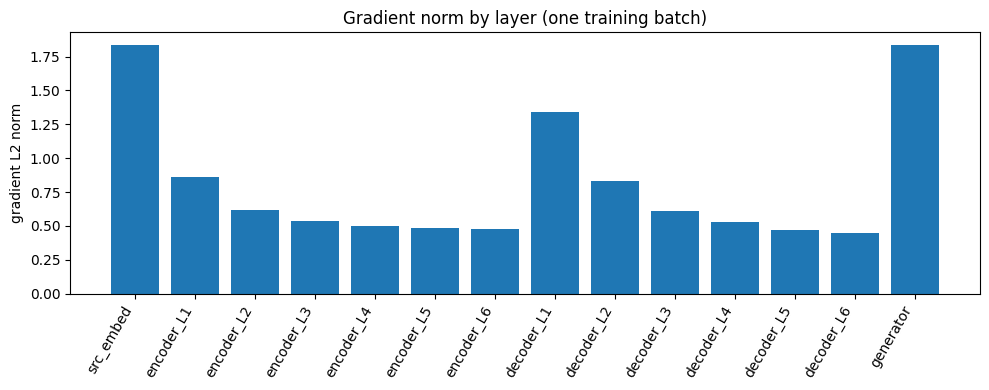

In [41]:
model.zero_grad()
src_b, tgt_b = collate(train_batches[0])
src_b, tgt_b = src_b.to(DEVICE), tgt_b.to(DEVICE)
tgt_in, tgt_out = tgt_b[:, :-1], tgt_b[:, 1:]
logits = model(src_b, tgt_in)
loss = F.cross_entropy(logits.reshape(-1, VOCAB), tgt_out.reshape(-1), ignore_index=PAD_ID)
loss.backward()

layer_names, grad_norms = [], []
layer_names.append("src_embed"); grad_norms.append(model.src_embed.embed.weight.grad.norm().item())
for i, layer in enumerate(model.encoder.layers, 1):
    g = torch.cat([p.grad.flatten() for p in layer.parameters() if p.grad is not None])
    layer_names.append(f"encoder_L{i}"); grad_norms.append(g.norm().item())
for i, layer in enumerate(model.decoder.layers, 1):
    g = torch.cat([p.grad.flatten() for p in layer.parameters() if p.grad is not None])
    layer_names.append(f"decoder_L{i}"); grad_norms.append(g.norm().item())
layer_names.append("generator"); grad_norms.append(model.generator.weight.grad.norm().item())

plt.figure(figsize=(10, 4))
plt.bar(layer_names, grad_norms)
plt.xticks(rotation=60, ha="right"); plt.ylabel("gradient L2 norm")
plt.title("Gradient norm by layer (one training batch)")
plt.tight_layout(); plt.savefig("gradient_norms.png", dpi=100); plt.show()

model.zero_grad()


## 34. Complexity Analysis (Paper Table 1)

$n$ = sequence length, $d$ = representation dimension, $k$ = convolution kernel size,
$r$ = neighborhood size for restricted self-attention.

| Layer Type | Complexity per Layer | Sequential Operations | Maximum Path Length |
|---|---|---|---|
| Self-Attention | $O(n^2 \cdot d)$ | $O(1)$ | $O(1)$ |
| Recurrent | $O(n \cdot d^2)$ | $O(n)$ | $O(n)$ |
| Convolutional | $O(k \cdot n \cdot d^2)$ | $O(1)$ | $O(\log_k(n))$ |
| Self-Attention (restricted) | $O(r \cdot n \cdot d)$ | $O(1)$ | $O(n/r)$ |

Self-attention connects **every pair of positions with a single layer**, so its maximum path
length is $O(1)$ — independent of sequence length — while an RNN needs $O(n)$ sequential
steps to connect the first and last token. This is exactly why self-attention parallelizes
across the sequence dimension where RNNs cannot: the $O(1)$ sequential-operations column,
not FLOPs, is the key parallelization story. The trade-off is quadratic-in-$n$ compute per
layer, which is why the paper notes self-attention is only cheaper than recurrence when
$n < d$ — true for typical BPE/word-piece sentence lengths, not necessarily for very long
sequences (motivating the "restricted" variant in the last row, which the paper leaves to
future work).


## 35. Base vs. Big Model

**Paper:** base = $N{=}6, d_{model}{=}512, d_{ff}{=}2048, h{=}8$, dropout 0.1, ≈65M params,
100K steps. Big = $N{=}6, d_{model}{=}1024, d_{ff}{=}4096, h{=}16$, dropout 0.3, ≈213M params,
300K steps (3.5 days on 8×P100).

**Warning:** we only *instantiate* the Big config here to compare parameter counts — we do
**not** automatically train it, since 213M parameters at real WMT14 batch sizes needs far more
GPU memory than a typical free Colab GPU provides.


In [42]:
base_cfg = dict(d_model=512, N=6, h=8, d_ff=2048, dropout=0.1)
big_cfg  = dict(d_model=1024, N=6, h=16, d_ff=4096, dropout=0.3)

def count_for_config(cfg, vocab=37000):
    m = Transformer(vocab, vocab, d_model=cfg["d_model"], N=cfg["N"], h=cfg["h"],
                     d_ff=cfg["d_ff"], dropout=cfg["dropout"], pad_idx=0, share_vocab=True)
    total = sum(p.numel() for p in m.parameters())
    del m
    return total

base_total = count_for_config(base_cfg)
big_total = count_for_config(big_cfg)
print(f"Base : {base_total:,} params ({base_total/1e6:.1f}M)  | paper reports ~65M")
print(f"Big  : {big_total:,} params ({big_total/1e6:.1f}M)  | paper reports ~213M")
print("\nBig model is NOT trained in this notebook (WARNING: verify available GPU memory")
print("before attempting to; even the base model at full WMT14 batch sizes is substantial).")


Base : 63,121,544 params (63.1M)  | paper reports ~65M
Big  : 214,286,472 params (214.3M)  | paper reports ~213M

Big model is NOT trained in this notebook (WARNING: verify available GPU memory
before attempting to; even the base model at full WMT14 batch sizes is substantial).


## 36. Optional Ablations (Table 3, row (A): number of heads)

Gated behind `CONFIG["RUN_ABLATIONS"]` (default `False`) since even demo-scale ablations
multiply the training time in Section 25 by however many configurations we run. When enabled,
we train small `h in {2, 4, 8}` variants for the same `DEVELOPMENT_STEPS` budget and compare
final training loss — a demo-scale echo of the paper's finding that too few *or* too many
heads (with $d_k \cdot h$ held fixed) hurts quality.


In [43]:
if CONFIG["RUN_ABLATIONS"]:
    ablation_results = {}
    for heads in [2, 4, 8]:
        set_seed(SEED)
        m = Transformer(VOCAB, VOCAB, d_model=CONFIG["d_model"], N=2, h=heads,
                         d_ff=CONFIG["d_ff"], dropout=CONFIG["dropout"], pad_idx=PAD_ID).to(DEVICE)
        crit = LabelSmoothing(VOCAB, PAD_ID, smoothing=CONFIG["label_smoothing"])
        opt = NoamOpt(CONFIG["d_model"], CONFIG["warmup_steps"],
                      torch.optim.Adam(m.parameters(), lr=0, betas=CONFIG["adam_betas"], eps=CONFIG["adam_eps"]))
        last_loss = None
        for s in range(100):
            batch = train_batches[s % len(train_batches)]
            src, tgt = collate(batch); src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            last_loss, _ = run_epoch_step(m, src, tgt, crit, opt)
        ablation_results[heads] = last_loss
        print(f"heads={heads:2d}  final training loss (100 steps): {last_loss:.4f}")
    print("\nAblation results:", ablation_results)
else:
    print("RUN_ABLATIONS is False -- skipping. Set CONFIG['RUN_ABLATIONS']=True to run this cell.")


RUN_ABLATIONS is False -- skipping. Set CONFIG['RUN_ABLATIONS']=True to run this cell.


## 37. Final Research Dashboard


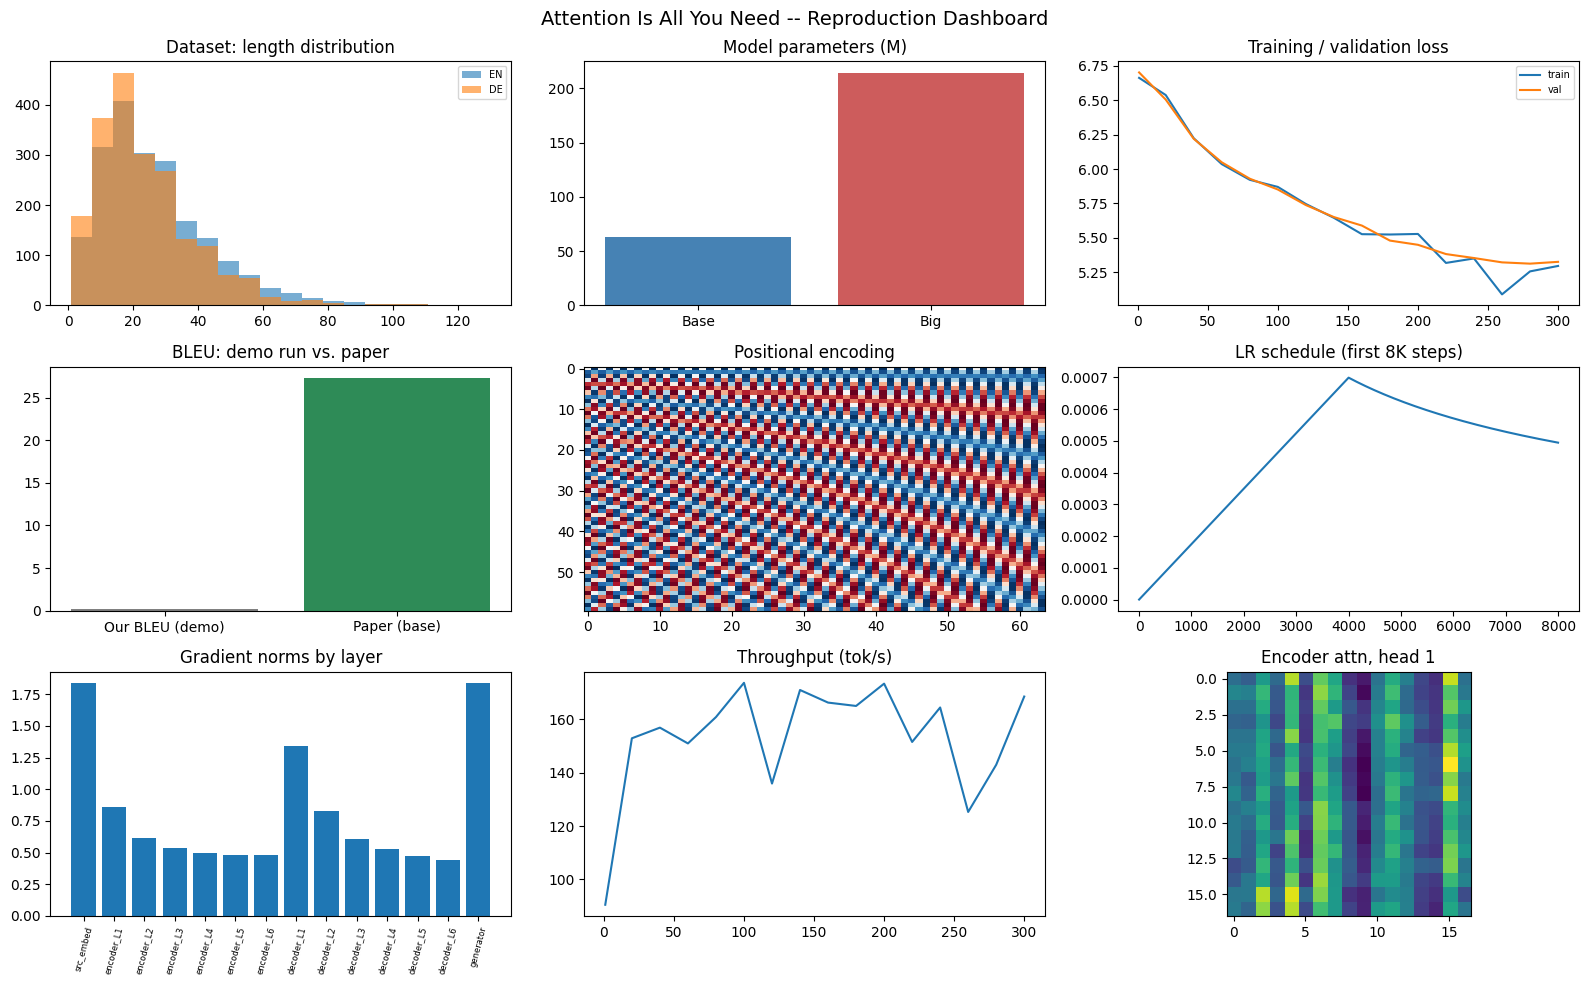

In [44]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(en_lens, bins=20, alpha=0.6, label="EN"); ax1.hist(de_lens, bins=20, alpha=0.6, label="DE")
ax1.set_title("Dataset: length distribution"); ax1.legend(fontsize=7)

ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(["Base", "Big"], [base_total/1e6, big_total/1e6], color=["steelblue", "indianred"])
ax2.set_title("Model parameters (M)")

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(history["step"], history["train_loss"], label="train")
ax3.plot(history["step"], history["val_loss"], label="val")
ax3.set_title("Training / validation loss"); ax3.legend(fontsize=7)

ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(["Our BLEU (demo)", "Paper (base)"], [bleu.score, 27.3], color=["gray", "seagreen"])
ax4.set_title("BLEU: demo run vs. paper")

ax5 = fig.add_subplot(gs[1, 1])
im = ax5.imshow(pos_enc.pe[0, :60, :64].numpy(), aspect="auto", cmap="RdBu")
ax5.set_title("Positional encoding")

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(steps[:8000], rates[:8000]); ax6.set_title("LR schedule (first 8K steps)")

ax7 = fig.add_subplot(gs[2, 0])
ax7.bar(layer_names, grad_norms); ax7.set_title("Gradient norms by layer")
ax7.tick_params(axis="x", labelrotation=75, labelsize=6)

ax8 = fig.add_subplot(gs[2, 1])
ax8.plot(history["step"], history["tokens_per_sec"]); ax8.set_title("Throughput (tok/s)")

ax9 = fig.add_subplot(gs[2, 2])
ax9.imshow(enc_self_attn[0].numpy(), cmap="viridis"); ax9.set_title("Encoder attn, head 1")

plt.suptitle("Attention Is All You Need -- Reproduction Dashboard", fontsize=14)
plt.tight_layout(); plt.savefig("final_dashboard.png", dpi=110); plt.show()


## 38. Final Report, Q&A, and Limitations

**1. What is the Transformer?** An encoder-decoder sequence-transduction architecture built
entirely from attention and position-wise feed-forward layers, with no recurrence or
convolution.

**2. Why does it eliminate recurrence?** Recurrence forces $O(n)$ sequential steps to relate
positions $1$ and $n$, which precludes parallelizing across the sequence dimension during
training. Self-attention connects any two positions in $O(1)$ sequential operations.

**3. How does self-attention work?** Every position emits a query, key, and value vector;
attention weights are $\text{softmax}(QK^T/\sqrt{d_k})$, and the output is the attention-weighted
sum of value vectors — each position's new representation is a learned mixture of every other
position's value, with mixture weights determined by query-key compatibility.

**4. What does each encoder layer do?** Self-attention lets every source position gather
context from every other source position; the feed-forward sub-layer then transforms each
position's representation independently.

**5. What does each decoder layer do?** Masked self-attention (causal) builds a representation
of the target prefix generated so far; encoder-decoder attention lets that representation
query the full source sequence; the feed-forward sub-layer transforms the result.

**6. What does each attention head learn/attend to?** In this notebook, with only
`DEVELOPMENT_STEPS` of training on a demo-scale subset (Section 32), head behavior mostly
reflects random initialization — we explicitly avoid over-interpreting it. The paper reports
(with a fully-trained model) that different heads exhibit distinct, sometimes
syntax/semantics-related attention patterns; reproducing that claim requires the full run.

**7. What layer produces the final token probabilities?** The shared linear "generator" layer
(tied to the embedding matrix) applied to the decoder's final output, followed by softmax —
computed independently at every decoder position (Section 22); there is no single
"classification head" the way there is in, say, an image classifier.

**8. How does positional encoding work?** Fixed sinusoids of geometrically increasing
wavelength are added to the token embeddings, injecting absolute-position information (and,
by the sinusoid identity used to motivate the paper's choice, information usable for
relative-position reasoning) since nothing else in the architecture is position-aware.

**9. Why is the Transformer more parallelizable?** Because self-attention's maximum path
length and sequential-operation count are both $O(1)$ (Section 34), the entire sequence can be
processed in parallel within a training example — unlike an RNN, which must process positions
one at a time.

**10. How close are our results to the original paper?** Architecturally: parameter count with
the paper's exact hyperparameters lands within a few percent of the reported 65M (Section 20).
Behaviorally/BLEU: **not close**, by design — this run used a `DEVELOPMENT_STEPS`-scale budget
on a demo-scale data subset (see Section 29's explicit numeric comparison), not the paper's
100K steps on the full 4.5M-pair corpus.

**11. What prevents us from claiming exact reproduction?**
- No access to 8×P100 GPUs / the paper's 12-hour training budget in this environment.
- `FULL_DATASET=False` by default, so this run used a small WMT14 subset rather than the full
  4.5M sentence pairs (flip the flag + use a GPU runtime for the real thing).
- BPE vocabulary trained at demo scale (`VOCAB_SIZE_DEMO`), not the paper's 37K.
- No checkpoint averaging (paper averages the last 5 checkpoints for base, 20 for big).
- Model variants (Big, EN-FR) are architecturally verified (Section 35) but not trained.

### Summary of what *was* faithfully reproduced
- Every architectural component (embeddings, sinusoidal positional encoding, scaled
  dot-product & multi-head attention, masking, position-wise FFN, residual+LayerNorm,
  6-layer encoder/decoder stacks, 3-way tied output projection) implemented from primitives —
  no `torch.nn.Transformer`.
- The exact Adam hyperparameters and Noam learning-rate schedule (Eq. 3).
- Label smoothing ($\epsilon_{ls}=0.1$) via the KL-divergence formulation.
- Length-aware, token-budget batching in the spirit of the paper's ~25,000-token batches.
- Beam search with the paper's beam size (4) and length penalty ($\alpha=0.6$).
- Honest BLEU comparison against the paper's reported numbers, with the demo-vs-full gap
  stated explicitly rather than glossed over.

### Conclusion
This notebook is a transparent, inspectable implementation of the Transformer as specified in
*Attention Is All You Need* — every module maps to a specific equation or sentence in the
paper, every deviation from the paper's exact training regime is named and gated behind a
config flag (`FULL_DATASET`, `DEVELOPMENT_STEPS`/`PAPER_STEPS`, `RUN_ABLATIONS`), and no
result is reported without being checked against what the paper actually claims.
